Load required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import scipy.io
%config InlineBackend.figure_format='retina'

Function to split dataset into training and test data with fixed number of training samples for each label

In [2]:
def fixed_split(X, y, train_samples_per_class):
    
    X_train, X_test, y_train, y_test , indices_train, indices_test = [], [], [], [], [], []
    
    unique_labels = np.unique(y)
    
    for label in range(1,np.max(unique_labels)+1):
        indices = np.where(y == label)[0]  # Get all indices for the current label
        
        n_train = train_samples_per_class
        if len(indices)/2 <= train_samples_per_class:
            n_train = int(np.floor(len(indices)/2))
        
        # Shuffle indices
        np.random.shuffle(indices)

        # Split into train and test
        train_indices = indices[:n_train]
        test_indices = indices[n_train:]

        # Append to train/test lists
        X_train.append(X[train_indices,:])
        X_test.append(X[test_indices,:])
        y_train.append(y[train_indices])
        y_test.append(y[test_indices])
        indices_train.append(train_indices)
        indices_test.append(test_indices)

    # Stack results
    X_train, X_test = np.vstack(X_train), np.vstack(X_test)
    y_train, y_test = np.hstack(y_train), np.hstack(y_test)
    indices_train, indices_test = np.hstack(indices_train), np.hstack(indices_test)
    
    return X_train, X_test, y_train, y_test, indices_train, indices_test

Function to perform PCA

In [3]:
def pca(X, nComponents, center = True):
    '''
        The data matrix X consists of sample rows and feature columns
    '''
    
    import numpy as np
    
    if center:
        mean_sample = np.mean(X, axis=0, keepdims=True)
        
        X_centered = X - mean_sample
    
        U, S, VT = np.linalg.svd(X_centered, full_matrices=False)
    
        components = VT[:nComponents,:]

        projected_X = X @ components.T
        
        #projected_mean = mean_sample @ components.T
        #projected_X = projected_mean + X @ components.T
    
    else:
        U, S, VT = np.linalg.svd(X, full_matrices=False)

        components = VT[:nComponents,:]
        
        projected_X = X @ components.T
        
    return projected_X, components

Load Data

In [4]:
data3D = scipy.io.loadmat("Data\Indian_pines_corrected.mat")
labels = scipy.io.loadmat("Data\Indian_pines_gt.mat")

View data

In [5]:
print(data3D.keys())
print(labels.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])
dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [6]:
data3D_array = data3D['indian_pines_corrected']

# Normalize 
data3D_array = data3D_array/np.max(data3D_array) #np.max(data3D_array, axis=(0,1), keepdims=True) # 

print(data3D_array.shape)
labels_array = labels['indian_pines_gt']
print(labels_array.shape)

nY = data3D_array.shape[0]
nX = data3D_array.shape[1]
nBands = data3D_array.shape[2]
nPix = nX*nY

min_label = np.min(labels_array)
max_label = np.max(labels_array)

(145, 145, 200)
(145, 145)


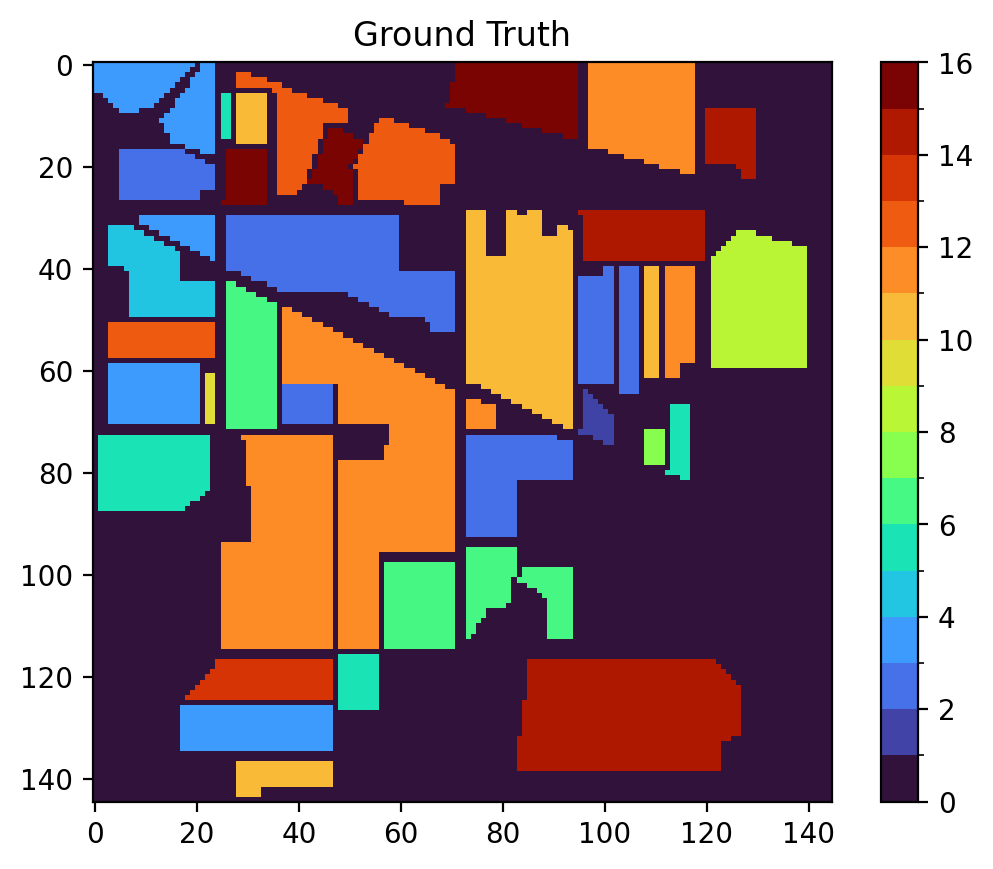

In [7]:
# Use Turbo colormap from Matplotlib
cmap = pl.cm.turbo

# Define discrete boundaries for the values (0 to 16)
bounds = np.arange(min_label, max_label+1, 1)  # Ensures correct mapping of colors
norm = BoundaryNorm(bounds, cmap.N)

pl.imshow(labels_array, cmap=cmap,norm=norm)
pl.colorbar()
pl.title(r"Ground Truth")
pl.show()

In [8]:
# Get number of pixels (samples) with each label
unique_labels = np.arange(min_label,max_label+1,1)
label_count = np.zeros_like(unique_labels)

for i in range(0,len(label_count)):
    label_count[i] = (labels_array == unique_labels[i]).sum()

label_count_df = pd.DataFrame({"Class Label":unique_labels, "Number of Samples":label_count})

print(label_count_df)

    Class Label  Number of Samples
0             0              10776
1             1                 46
2             2               1428
3             3                830
4             4                237
5             5                483
6             6                730
7             7                 28
8             8                478
9             9                 20
10           10                972
11           11               2455
12           12                593
13           13                205
14           14               1265
15           15                386
16           16                 93


SLIC Superpixelization

In [9]:
# Form data array of form (Rows -> samples (pixels), Columns -> features (bands))
# Note that in matlab, data array should be of form (Rows -> features (bands), Columns -> samples (pixels)) 

data2D_array = np.zeros((nPix, nBands)) #data3D_array.reshape(nPix, nBands)

for i in range(nBands):
    data2D_array[:,i] = data3D_array[:,:,i].reshape(nPix)
    
labels2D_array = labels_array.reshape(nPix)
print(data2D_array.shape)

# Get mean pixel (sample)
mean_pixel = np.mean(data2D_array,axis=0,keepdims=True)

#data2D_array = data2D_array - mean_pixel
# Get first principal component 

from sklearn.decomposition import PCA

# Perform PCA
#X_pca = PCA(n_components=1).fit_transform(data2D_array)  # Project data onto the first PC

X_pca, components = pca(data2D_array, 1)

(21025, 200)


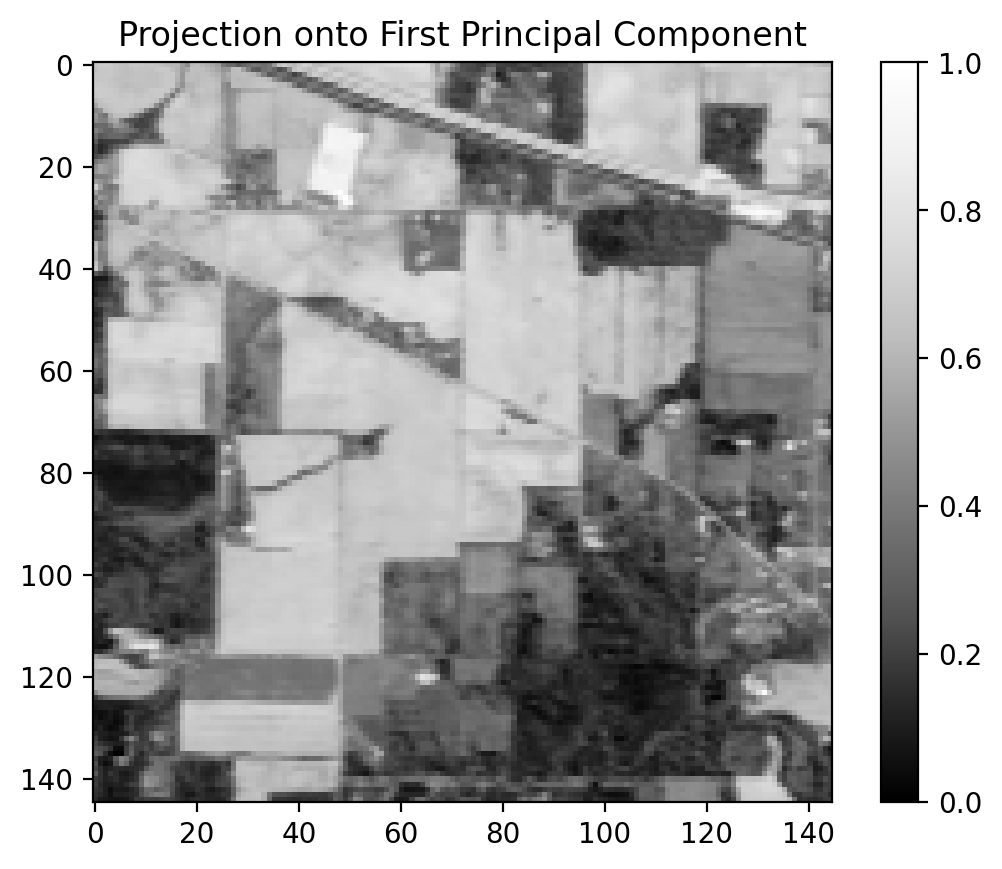

In [10]:
# Reshape into 2D image
img_pca = X_pca.reshape(nY,nX)

# Normalize to range [0,1] for imshow
img_pca = (img_pca - np.min(img_pca))/(np.max(img_pca)-np.min(img_pca))

pl.imshow(img_pca, cmap='Greys_r')
pl.colorbar()
pl.title('Projection onto First Principal Component')
pl.show()

SLIC number of segments: 97


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037975464883877076..1.0016150311814884].


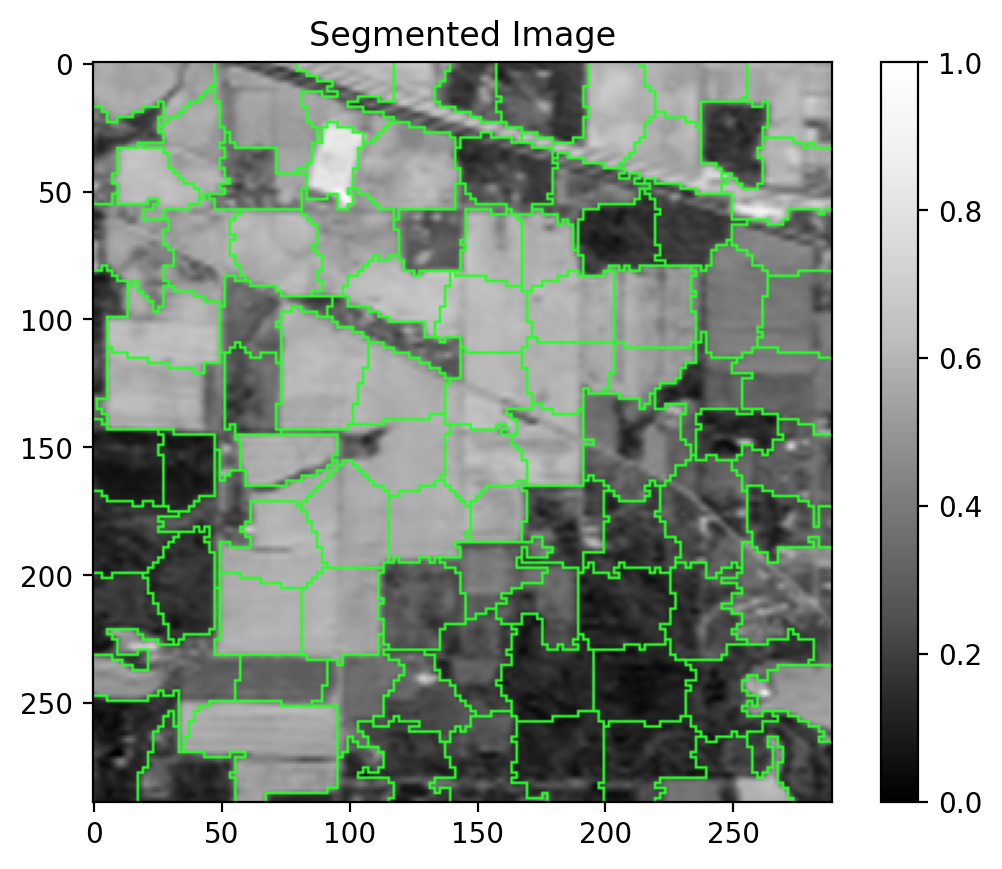

In [11]:
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
segments = slic(img_pca, channel_axis=None, n_segments=100, sigma=0.05, compactness=0.2,start_label=0)
nSegments = len(np.unique(segments))
print(f'SLIC number of segments: {nSegments}')

pl.imshow(mark_boundaries(img_pca, segments,color=(0.15, 1.0, 0.15),mode='subpixel'),cmap='Greys_r')
pl.title(r"Segmented Image")
pl.colorbar()
pl.show()

In [12]:
segments_array = segments.reshape(nPix)

data2D_array_segmented = []
segmented_arrays_pixels = []

for i in range(0,nSegments):
    segmenti_array =  np.empty((0, nBands))
    segmenti_indices_array =  np.array([])
    data2D_array_segmented.append(segmenti_array)
    segmented_arrays_pixels.append(segmenti_indices_array)
    
for i in range(0,nPix):
    data2D_array_segmented[int(segments_array[i])] = np.vstack([data2D_array_segmented[segments_array[i]], data2D_array[i,:]])
    segmented_arrays_pixels[int(segments_array[i])] = np.append(segmented_arrays_pixels[int(segments_array[i])], int(i))
    

Perform PCA on each superpixel

In [13]:
nComponents = 30

data2D_array_segmented_reduced = []
mean_pixel_segmented_reduced = []

for i in range(0,nSegments):
    #pca = PCA(n_components=nComponents)
    #local_mean_pixel = np.mean(data2D_array_segmented[i],axis=0,keepdims=True)
    #segmenti_array =  pca.fit_transform(data2D_array_segmented[i]) 
    #transformation_matrix = pca.components_.T
    #transformed_mean_pixel = local_mean_pixel @ transformation_matrix
    #data2D_array_segmented_reduced.append(segmenti_array + transformed_mean_pixel)
    #mean_pixel_segmented_reduced.append(transformed_mean_pixel)
    
    segmenti_array, components = pca(data2D_array_segmented[i], nComponents, center=True)
    data2D_array_segmented_reduced.append(segmenti_array)


In [14]:
# Reassemble 2D data array 
data2D_array_reduced = np.zeros((nPix,nComponents))
print(data2D_array_reduced.shape)
for i in range(0,nSegments):
    #mean_pixel_reduced = mean_pixel_segmented_reduced[i]
    for j in range(0,len(segmented_arrays_pixels[i])):
        pixel_index = int(segmented_arrays_pixels[i][j])
        pixel_data_reduced =  data2D_array_segmented_reduced[i][j,:] #+ mean_pixel_reduced
        data2D_array_reduced[pixel_index,:] = pixel_data_reduced
        
# Reassemble 3D data array
data3D_array_reduced = data2D_array_reduced.reshape(nY,nX,nComponents)


(21025, 30)


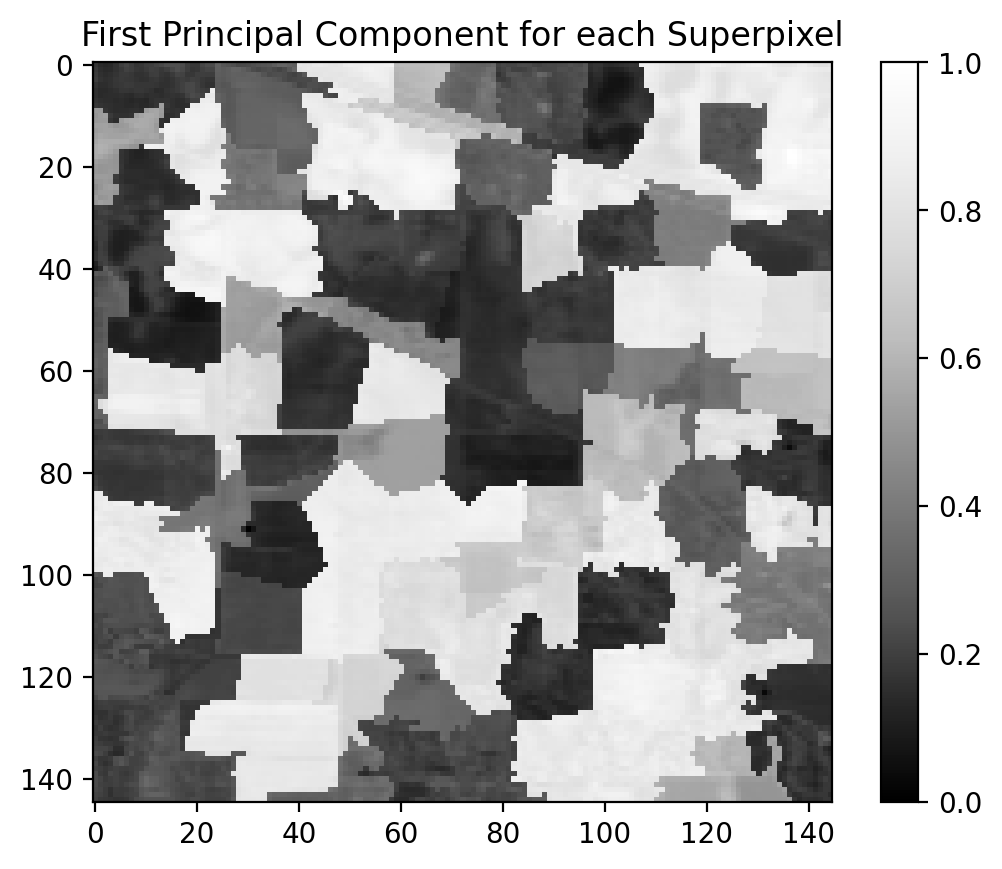

In [15]:
# Plot first principal component for each segment
X_spca, components = pca(data2D_array_reduced, 1)

img_spca = X_spca.reshape(nY,nX)
img_spca = (img_spca - np.min(img_spca))/(np.max(img_spca)-np.min(img_spca))
pl.imshow(img_spca,cmap='Greys_r')
pl.colorbar()
pl.title(r'First Principal Component for each Superpixel')
pl.show()

Perform SVM Classification on reduced data


In [16]:
# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

# Create indices for tracking
indices = np.arange(nPix)

# Split data into 30 training samples per label and remaining test samples

X_train, X_test, y_train, y_test, train_idx, test_idx = fixed_split(data2D_array_reduced, labels2D_array, 30)

#X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(data2D_array_reduced, labels2D_array, indices, test_size=0.7)

# Convert 1D indices back to 2D coordinates
rows, cols = np.unravel_index(indices, img_pca.shape)
'''
# Plot the image
pl.imshow(img_pca, cmap="Greys_r")
pl.scatter(cols, rows, color='red', s=0.1)  # Highlight pixels in red
pl.title("Training Pixels")
pl.show()
'''


'\n# Plot the image\npl.imshow(img_pca, cmap="Greys_r")\npl.scatter(cols, rows, color=\'red\', s=0.1)  # Highlight pixels in red\npl.title("Training Pixels")\npl.show()\n'

In [17]:
# Create a classifier: a support vector classifier
clf = svm.SVC(kernel = 'rbf')

# Define parameter grid
param_grid = {'gamma': [0.01, 0.03, 0.1, 0.3, 0.5, 0.7, 1, 3, 10, 30, 100], 'C': [0.1, 0.3, 1, 3, 1e1, 3e1, 1e2, 3e2, 1e3, 3e3, 1e4, 3e4, 1e5]}

from sklearn.model_selection import GridSearchCV

# Use GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


Best parameters: {'C': 100.0, 'gamma': 0.3}
Best cross-validation score: 0.9313740856844304


In [18]:
gamma = grid_search.best_params_['gamma']
C = grid_search.best_params_['C']

clf = svm.SVC(kernel='rbf',C=C,gamma=gamma)

clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
predicted = clf.predict(X_test)

# Generate classification report
report = metrics.classification_report(y_test, predicted, output_dict=True)

print(
    f"Classification report for classifier {svm}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

# Extract overall accuracy
overall_accuracy = report["accuracy"]
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Classification report for classifier <module 'sklearn.svm' from 'c:\\Users\\shubh\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\sklearn\\svm\\__init__.py'>:
              precision    recall  f1-score   support

           1       0.95      0.91      0.93        23
           2       0.86      0.86      0.86      1398
           3       0.90      0.88      0.89       800
           4       0.77      1.00      0.87       207
           5       0.98      0.84      0.90       453
           6       1.00      1.00      1.00       700
           7       0.76      0.93      0.84        14
           8       0.95      0.90      0.92       448
           9       0.91      1.00      0.95        10
          10       0.80      0.85      0.82       942
          11       0.94      0.90      0.92      2425
          12       0.92      0.91      0.92       563
          13       1.00      0.98      0.99       175
          14       0.95      1.00      0.97      1235
          15

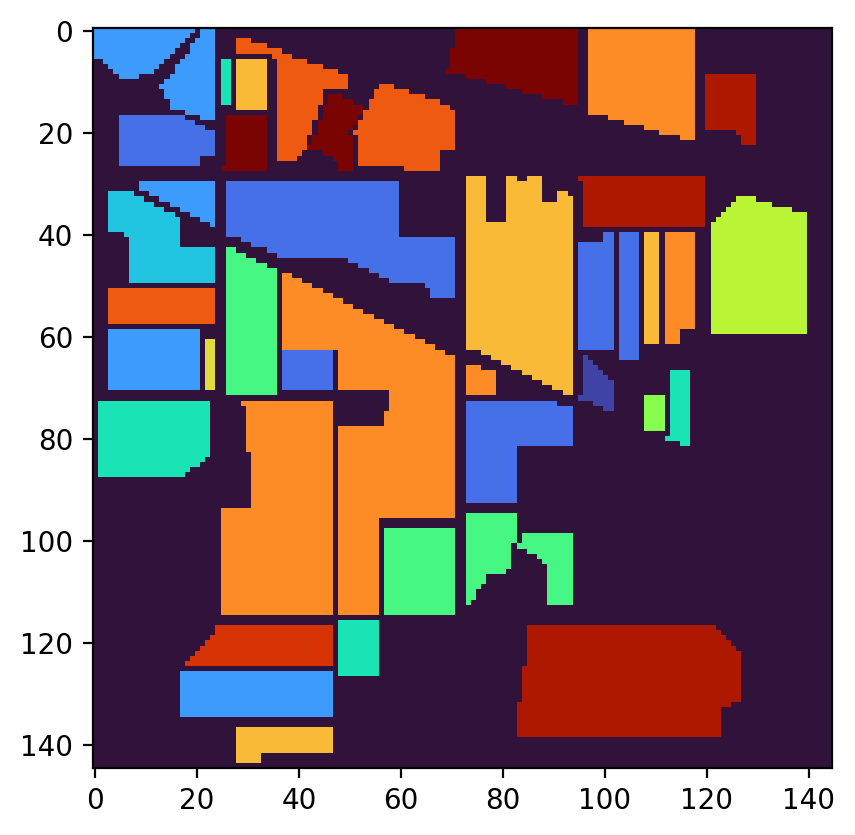

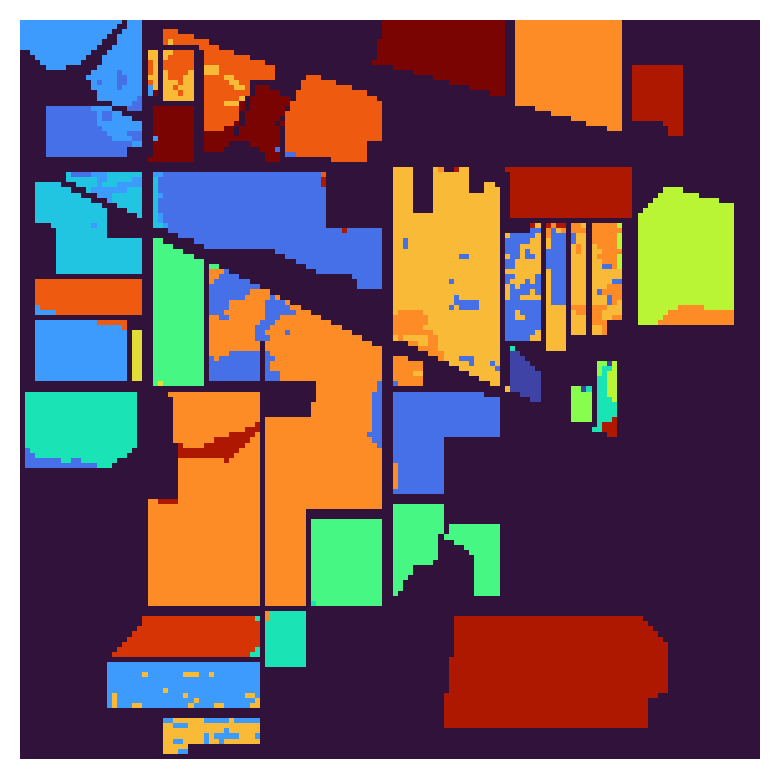

In [19]:
# Show predicted classification

labels_array_predicted = np.zeros(nPix)

labels_array_predicted[labels2D_array != 0] = clf.predict(data2D_array_reduced[labels2D_array != 0,:])

labels2D_array_predicted = labels_array_predicted.reshape(nY,nX)

pl.imshow(labels_array, cmap=cmap,norm=norm)
#pl.colorbar()
#pl.title(r"Ground Truth")
pl.show()
pl.imshow(labels2D_array_predicted, cmap=cmap,norm=norm)
#pl.colorbar()
#pl.title(r"Predicted Classification")
pl.axis('off')
pl.savefig('SuperPCA.png',dpi=600)
pl.show()